In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [3]:
metadata = TrainingInfo.load_metadata()

In [5]:
base_exp_name = "CR_fvt_training_ensemble_max"
pull_dicts = {}

fname = f"pull_by_hashes_smeared_max_{base_exp_name}"
pull_dicts = pickle.load(open(f"./data/pulls/{fname}.pkl", "rb"))

In [6]:
from scipy.stats import chi2

def get_pull(num: np.array, den: np.array):
    pull = np.zeros_like(num)
    nz = den > 0
    pull[nz] = num[nz] / np.sqrt(den[nz])
    return pull

chi2_zs = {df: chi2.ppf(0.95, df) for df in range(1, 300)}

for hash_ in pull_dicts:
    hparams = metadata[hash_]
    signal_ratio = hparams["dataset"]["signal_ratio"]
    SR_size = hparams["signal_region"]["4b_in_SR"]    
    sr_stats_hash = hparams["signal_region"]["SR_stats_hashes"][0]
    sr_stats_type = hparams["signal_region"]["stats_type"]
    seed = hparams["dataset"]["seed"]
    if sr_stats_type == "fvt":
        noise_scale = np.inf
    else:
        noise_scale = metadata[sr_stats_hash]["smearing"]["noise_scale"]
    
    for v in pull_dicts[hash_]:
        binning_mode = v["binning_mode"]
        nbins = v["nbins"]
        hists = v["hists"]
        hist_3b_rw = hists["3b_rw"]
        hist_3b_rw_sq = hists["3b_rw_sq"]
        hist_4b = hists["4b"]
        hist_4b_sq = hists["4b_sq"]
        var_o1 = hists["var_o1"]
        var_o2 = hists["var_o2"]
        hist_3b_o1 = hists["3b_corrected_o1"]
        hist_3b_o2 = hists["3b_corrected_o2"]
        hist_signal = hists["signal"]
        hist_bg4b = hists["bg4b"]
        
        if binning_mode == "train":
            var_o0 = hist_4b_sq + hist_3b_rw_sq
        else:
            var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

        v["signal_ratio"] = signal_ratio
        v["SR_size"] = SR_size
        v["noise_scale"] = noise_scale
        v["n_eff_bins"] = np.sum(var_o0 > 0)
        pull_o0 = get_pull(hist_4b - hist_3b_rw, var_o0)
        pull_o1 = get_pull(hist_4b - hist_3b_o1, var_o1)
        pull_o2 = get_pull(hist_4b - hist_3b_o2, var_o2)
        pull_signal = get_pull(hist_signal, var_o0)
        pull_bg4b = get_pull(hist_bg4b - hist_3b_rw, var_o0)
        v["pull_o0"] = pull_o0
        v["pull_o1"] = pull_o1
        v["pull_o2"] = pull_o2
        v["pull_signal"] = pull_signal
        v["pull_bg4b"] = pull_bg4b
        
        v["pull_o0_sq_sum"] = np.sum(pull_o0**2)
        v["pull_o1_sq_sum"] = np.sum(pull_o1**2)
        v["pull_o2_sq_sum"] = np.sum(pull_o2**2)
        v["pull_signal_sq_sum"] = np.sum(pull_signal**2)
        v["pull_bg4b_sq_sum"] = np.sum(pull_bg4b**2)
        v["seed"] = seed
        
        v["rejected_o0"] = v["pull_o0_sq_sum"] > chi2_zs[v["n_eff_bins"]]
        v["rejected_o1"] = v["pull_o1_sq_sum"] > chi2_zs[v["n_eff_bins"] - 1]
        v["rejected_o2"] = v["pull_o2_sq_sum"] > chi2_zs[v["n_eff_bins"] - 2]

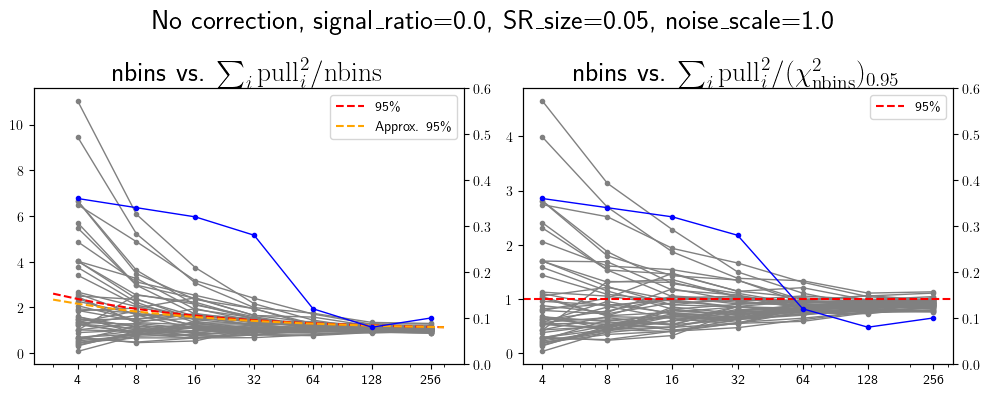

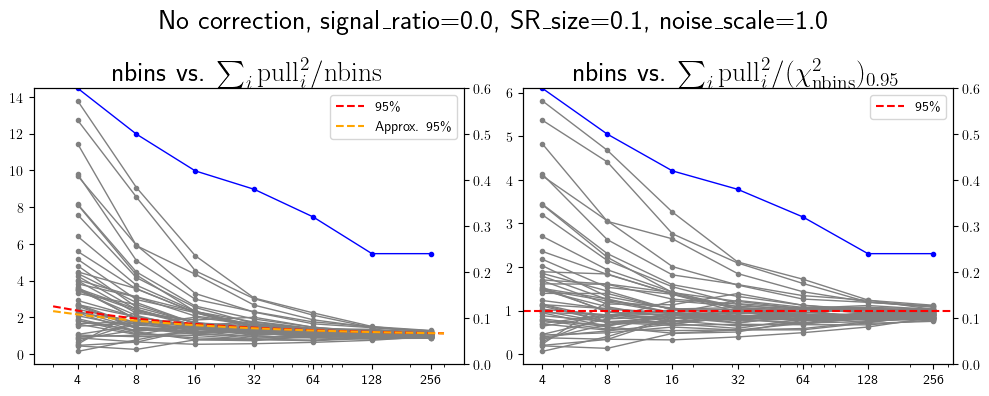

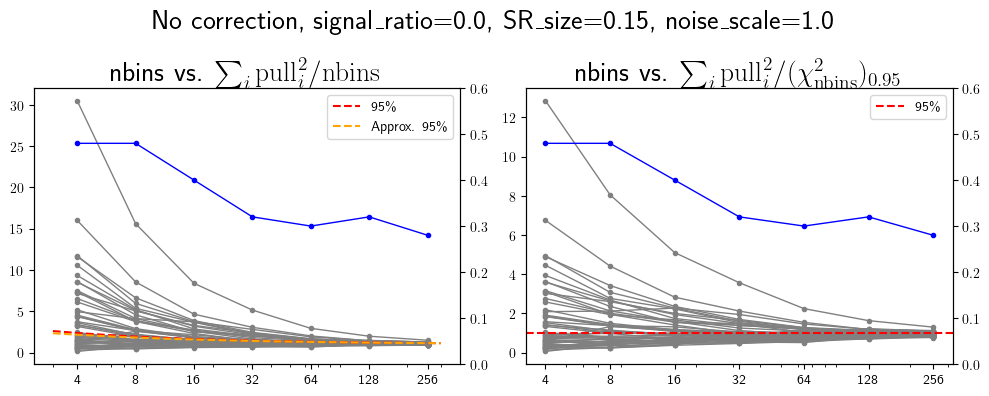

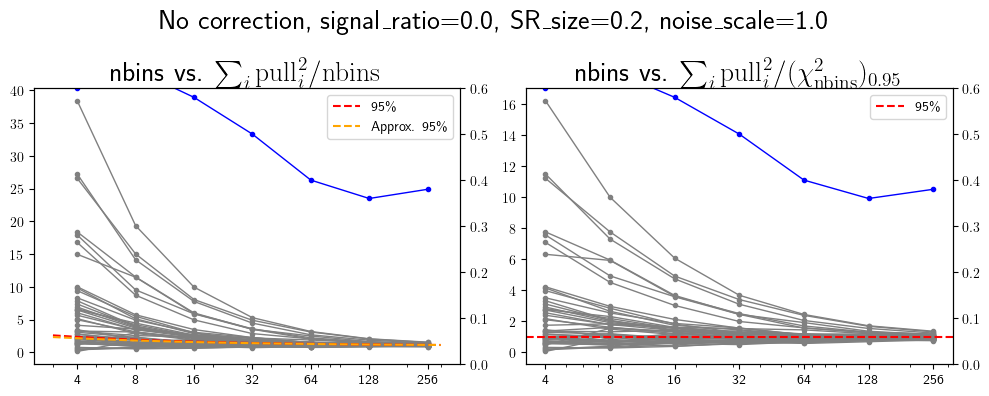

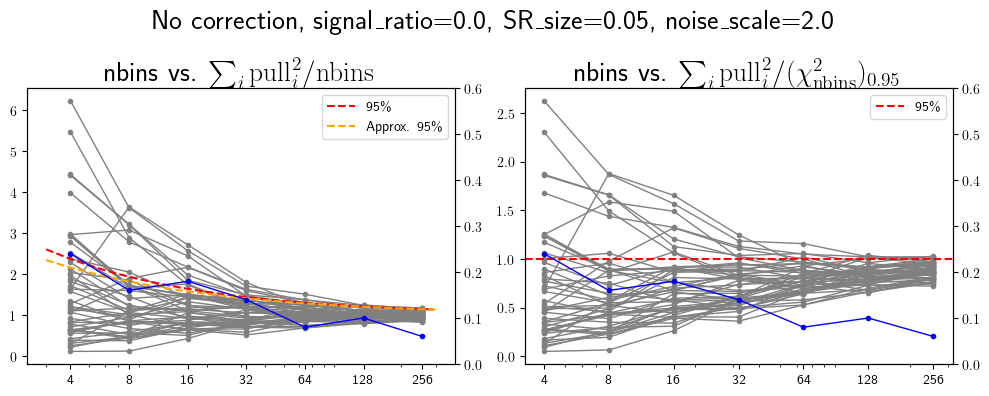

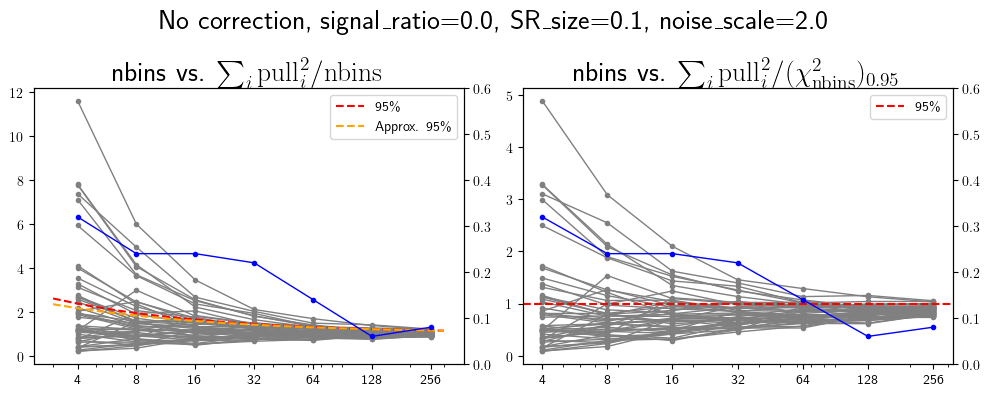

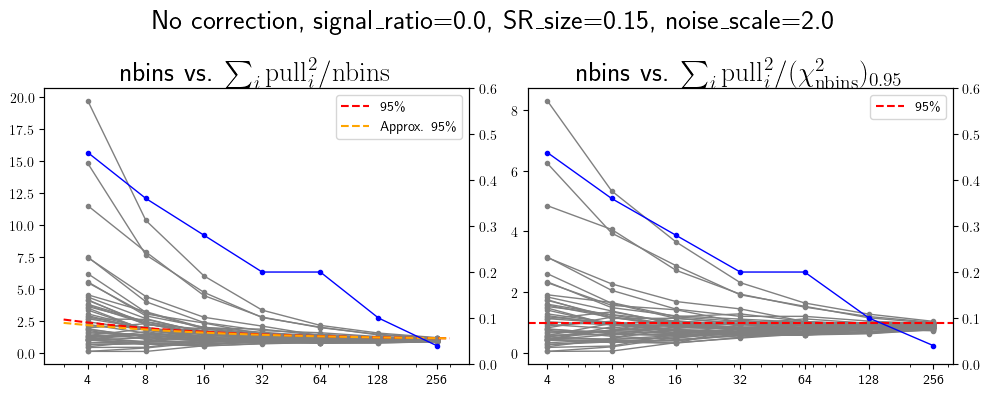

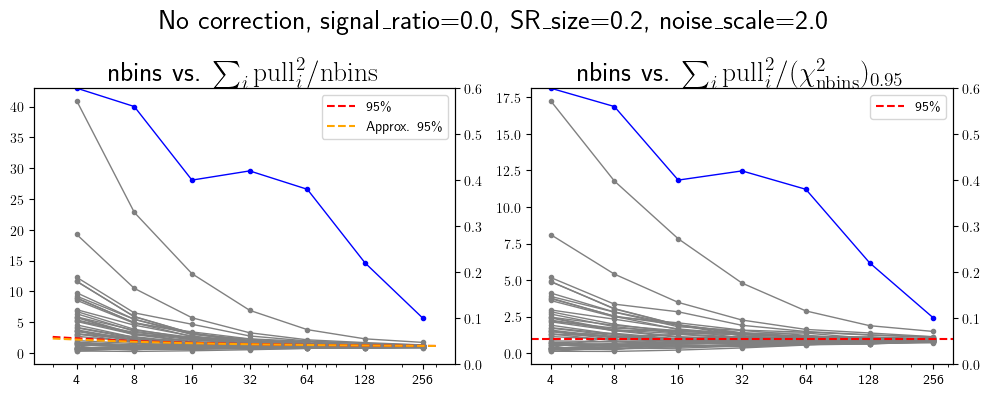

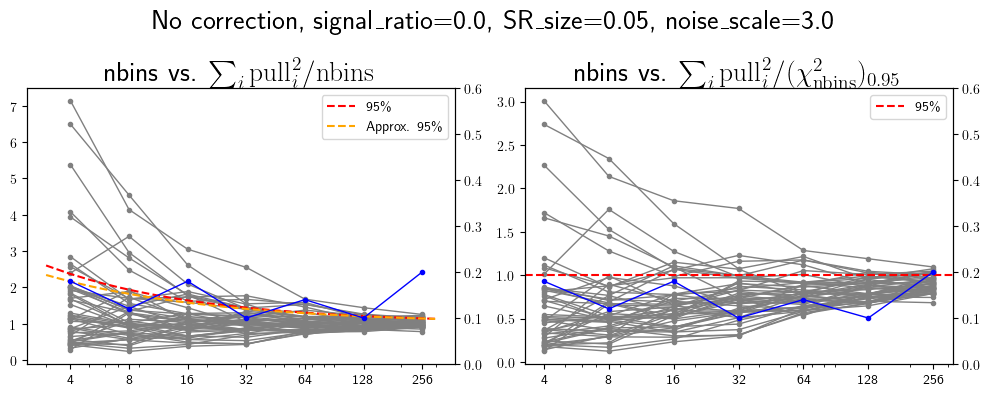

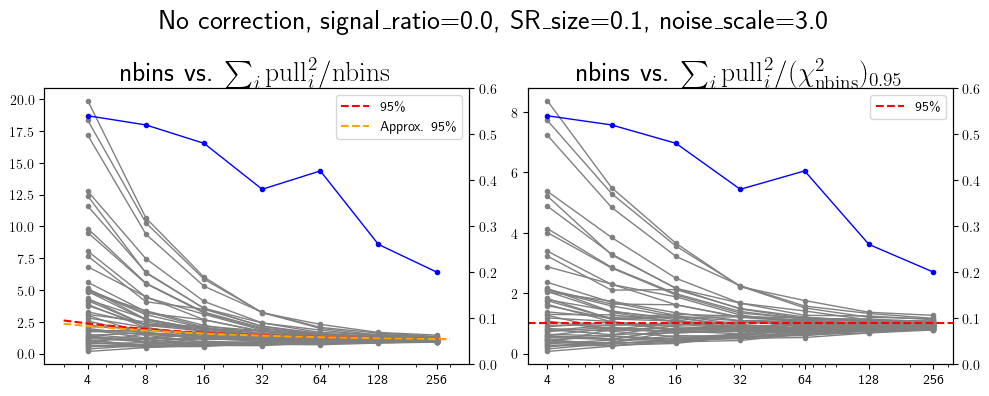

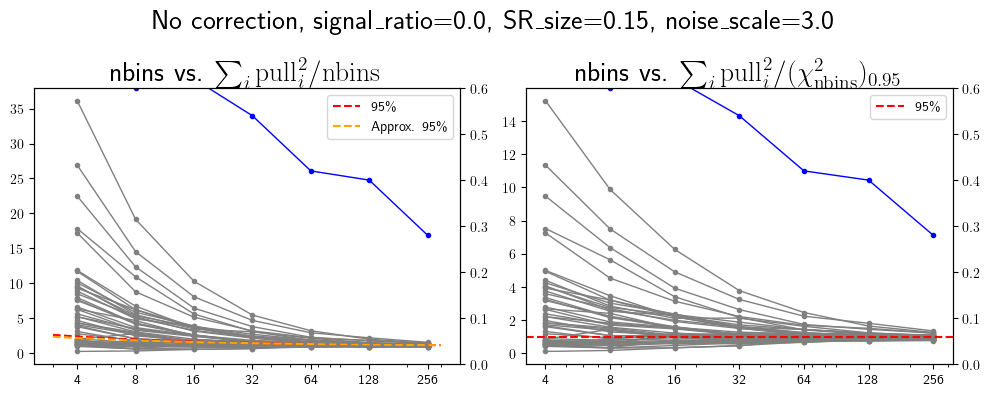

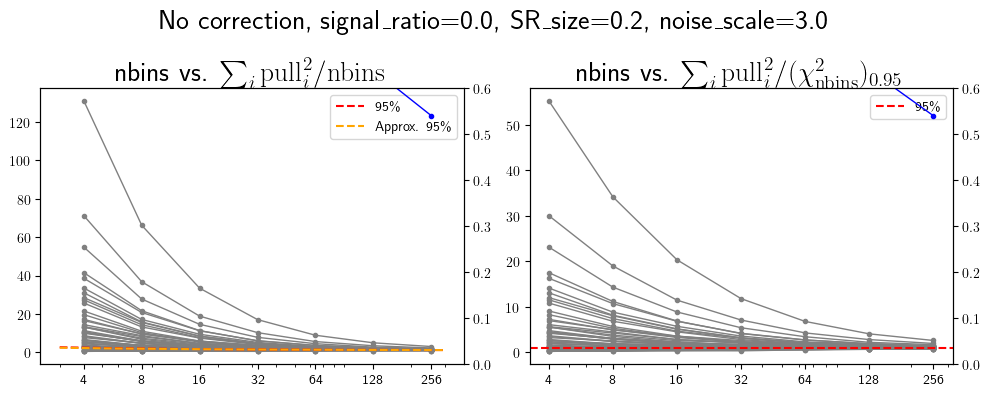

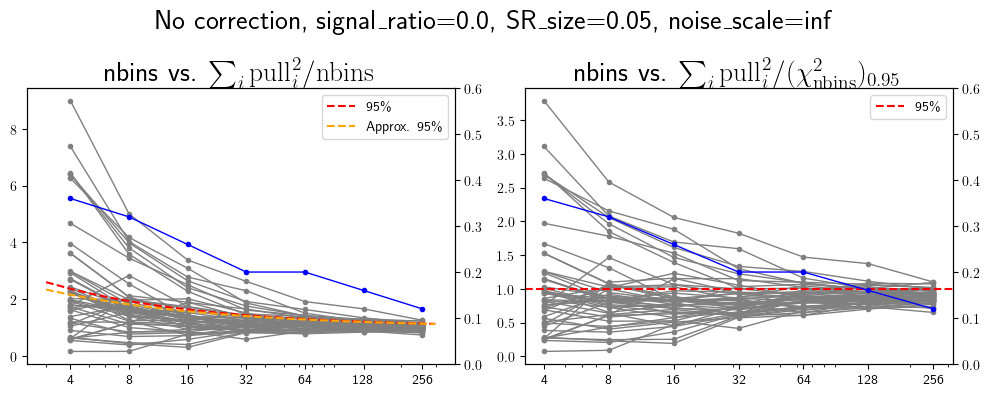

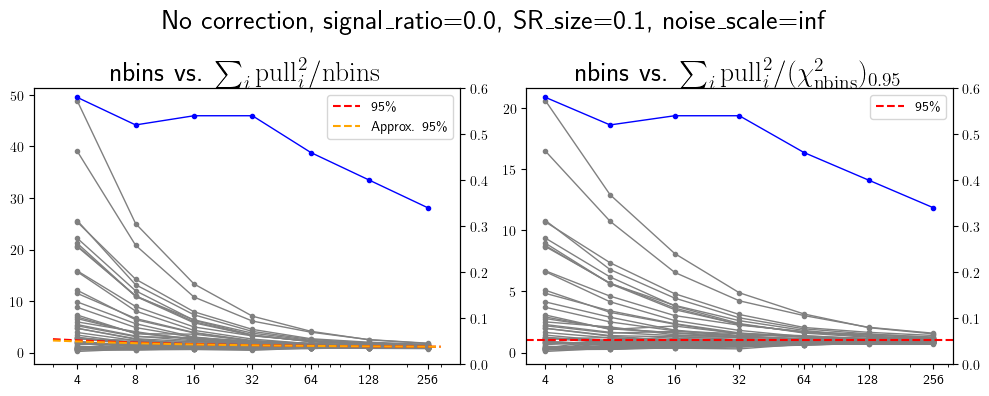

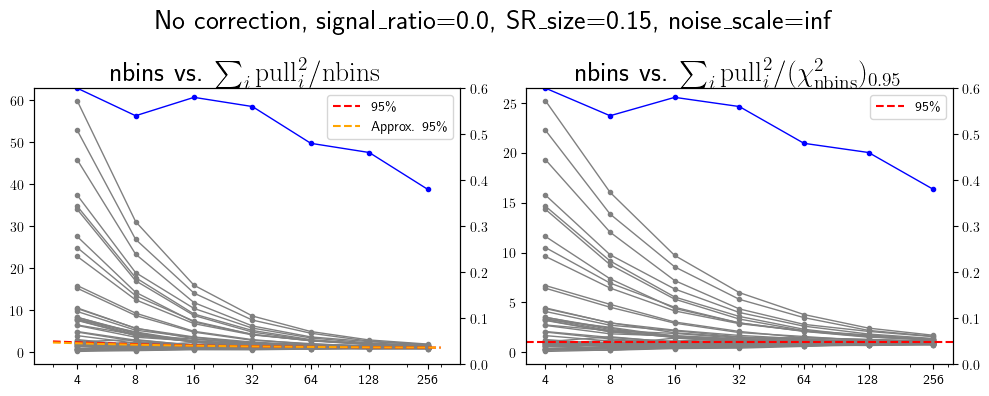

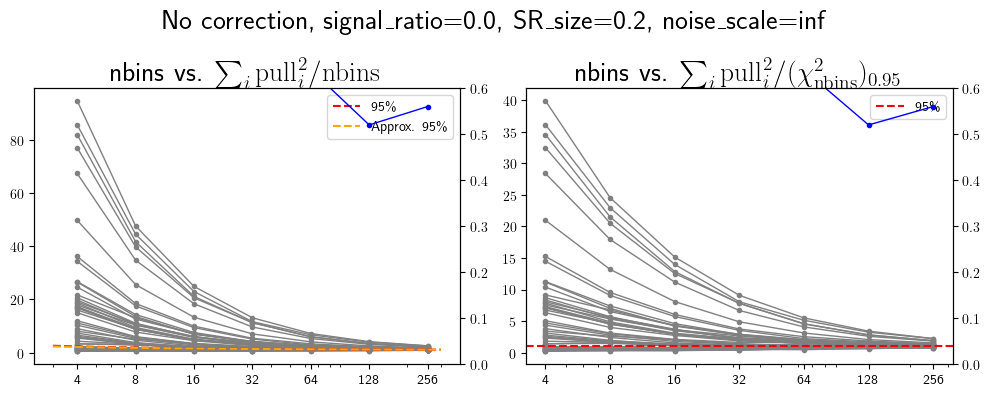

In [7]:
from scipy.stats import chi2, norm
signal_ratio = 0.0
noise_scale = 2.0
for noise_scale in [1.0, 2.0, 3.0, np.inf]:
    for SR_size in [0.05, 0.1, 0.15, 0.2]:
        pull_dicts_null = {k: v for k, v in pull_dicts.items() if (v[0]["signal_ratio"] == signal_ratio 
                                                                    and v[0]["SR_size"] == SR_size
                                                                    and v[0]["noise_scale"] == noise_scale
                                                                    )}    
        pull_list = []
        for hash_ in pull_dicts_null:
            pull_list.extend(pull_dicts_null[hash_])

        pull_df = pd.DataFrame(pull_list)

        tmp_df = pull_df.loc[pull_df["binning_mode"] == "train", ["nbins", "n_eff_bins", 
                                                                "rejected_o0", "rejected_o1", "rejected_o2",
                                                                "pull_o0_sq_sum", "pull_o1_sq_sum", "pull_o2_sq_sum", "seed"]]
        tmp_df_grouped = tmp_df.groupby("seed")

        # fig, ax = plt.subplots(figsize=(10, 5))
        # fig.suptitle(f"No correction, signal_ratio={signal_ratio}, SR_size={SR_size}, noise_scale={noise_scale}")
        # for seed in range(50):
        #     tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
        #     ax.plot(tmp["n_eff_bins"], tmp["pull_o0_sq_sum"] - tmp["n_eff_bins"], marker="o", linewidth=1, 
        #             color="gray")
        # ax.set_xticks([2**i for i in range(2, 9)])
        # plt.show()

        fig, axs = plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
        fig.suptitle(f"No correction, signal_ratio={signal_ratio}, SR_size={SR_size}, noise_scale={noise_scale}")
        axs[0].set_title(r"nbins vs. $\sum_i {\mathrm{pull}_i^2} / \mathrm{nbins}$")
        for seed in range(50):
            tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
            axs[0].plot(tmp["n_eff_bins"], tmp["pull_o0_sq_sum"] / tmp["n_eff_bins"], marker="o", linewidth=1, 
                    color="gray")
        ax2 = axs[0].twinx()
        nbins_list = 2 ** np.arange(2, 9)
        ax2.plot(nbins_list, tmp_df.groupby("nbins")["rejected_o0"].mean(), marker="o", linewidth=1, color="blue", label="Rejection rate")
        chi2_list = np.arange(3, 300)
        axs[0].plot(chi2_list, chi2.ppf(0.95, chi2_list) / chi2_list, label="95\%", linestyle="--", color="red")    
        axs[0].plot(chi2_list, 1 + norm.ppf(0.95) * np.sqrt(2 / chi2_list), label="Approx. 95\%", linestyle="--", color="orange")    
        ax2.set_ylim(0, 0.6)
        axs[0].set_xscale("log")
        axs[0].set_xticks([2**i for i in range(2, 9)])
        axs[0].set_xticklabels([2**i for i in range(2, 9)])
        axs[0].legend()
        
        axs[1].set_title(r"nbins vs. $\sum_i {\mathrm{pull}_i^2} / (\chi^2_{\mathrm{nbins}})_{0.95}$")
        for seed in range(50):
            tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
            axs[1].plot(tmp["n_eff_bins"], tmp["pull_o0_sq_sum"] / chi2.ppf(0.95, tmp["n_eff_bins"]), marker="o", linewidth=1, 
                    color="gray")
        ax2 = axs[1].twinx()
        nbins_list = 2 ** np.arange(2, 9)
        ax2.plot(nbins_list, tmp_df.groupby("nbins")["rejected_o0"].mean(), marker="o", linewidth=1, color="blue", label="Rejection rate")
        chi2_list = np.arange(3, 300)
        ax2.set_ylim(0, 0.6)
        axs[1].axhline(1, label="95\%", linestyle="--", color="red")    
        axs[1].set_xscale("log")
        axs[1].set_xticks([2**i for i in range(2, 9)])
        axs[1].set_xticklabels([2**i for i in range(2, 9)])
        axs[1].legend()
        plt.tight_layout()
        plt.show()

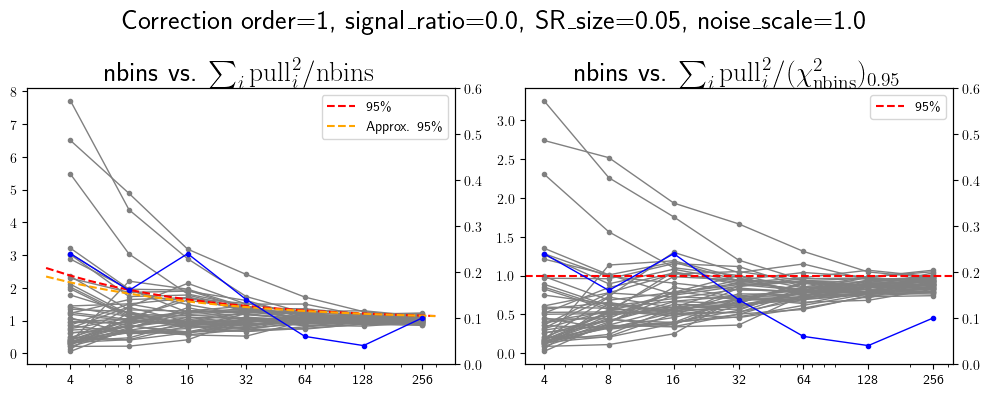

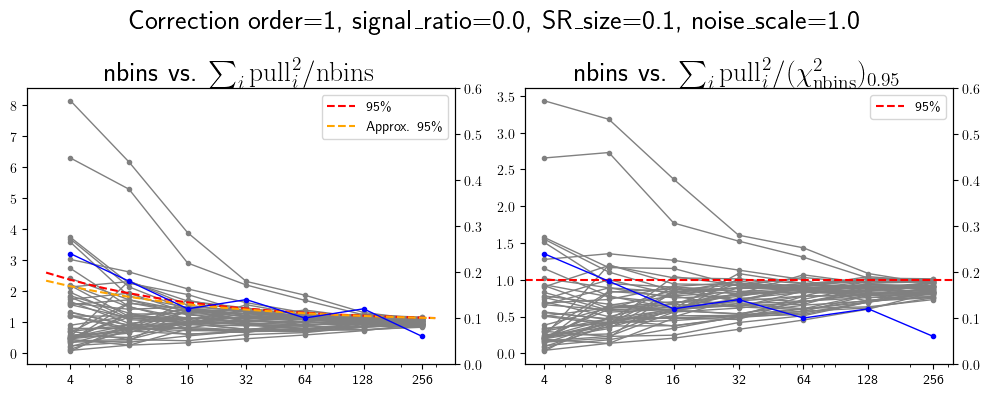

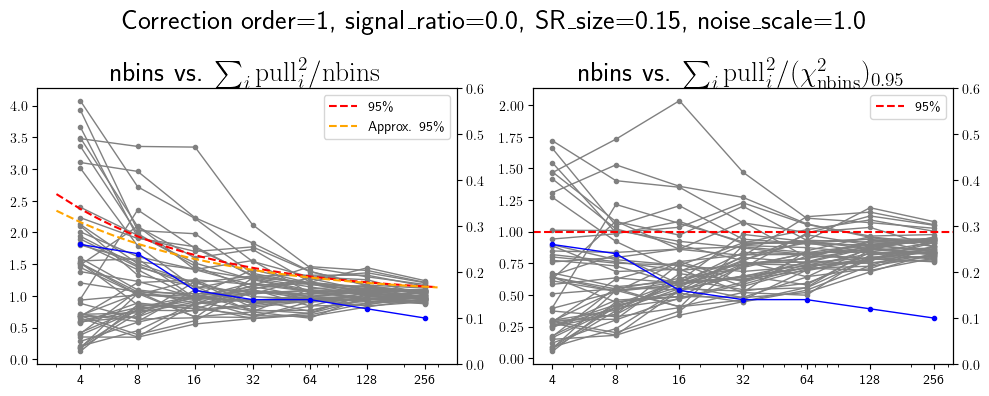

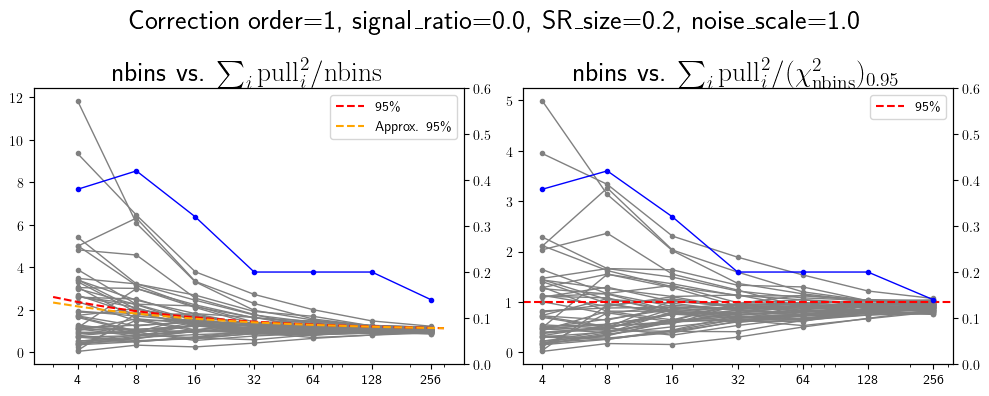

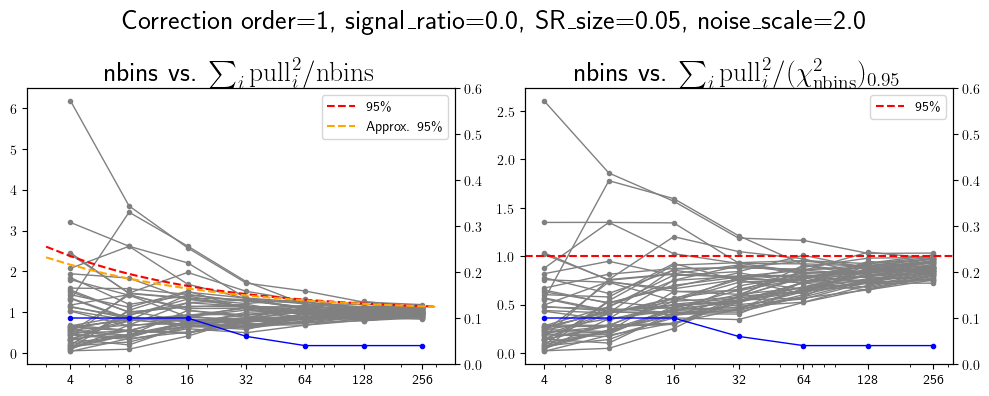

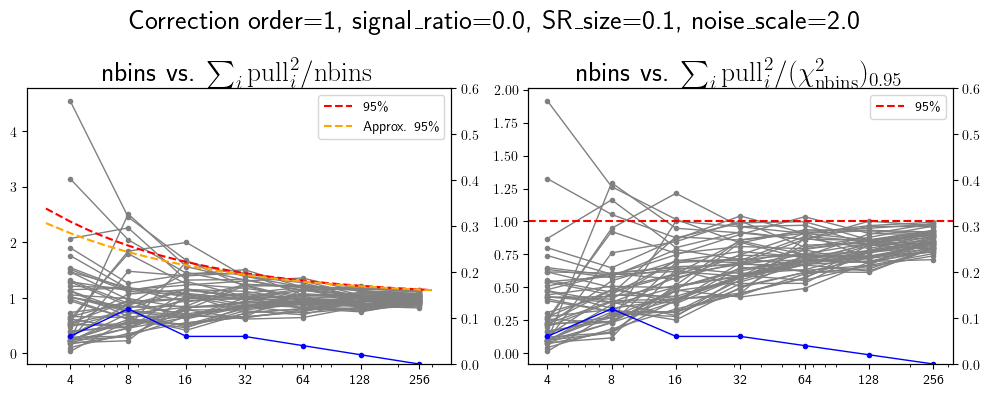

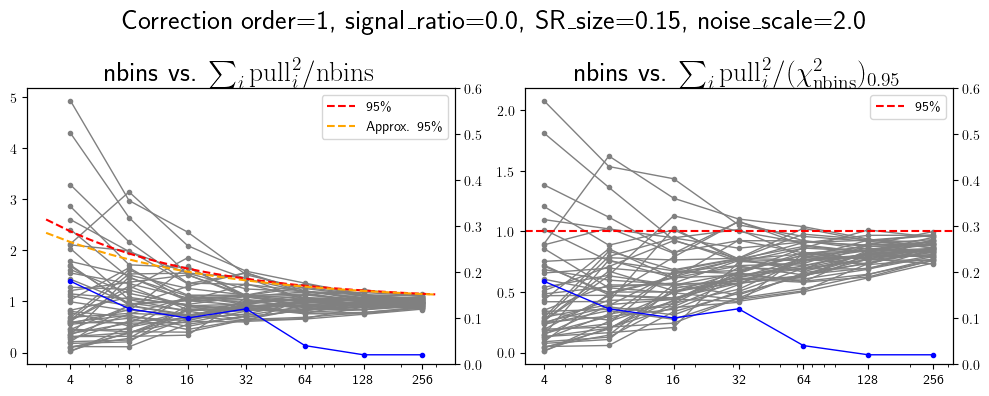

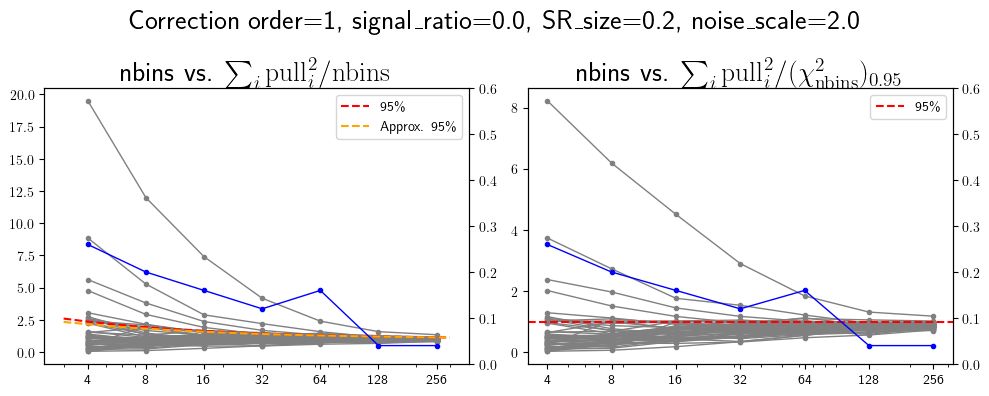

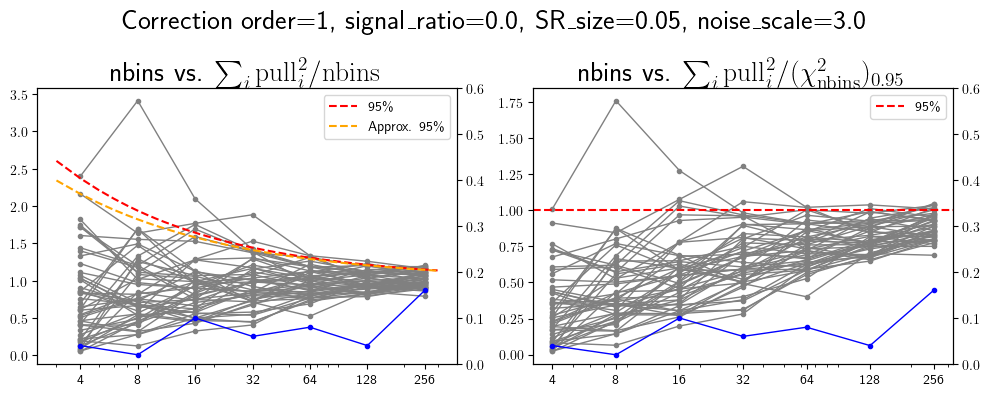

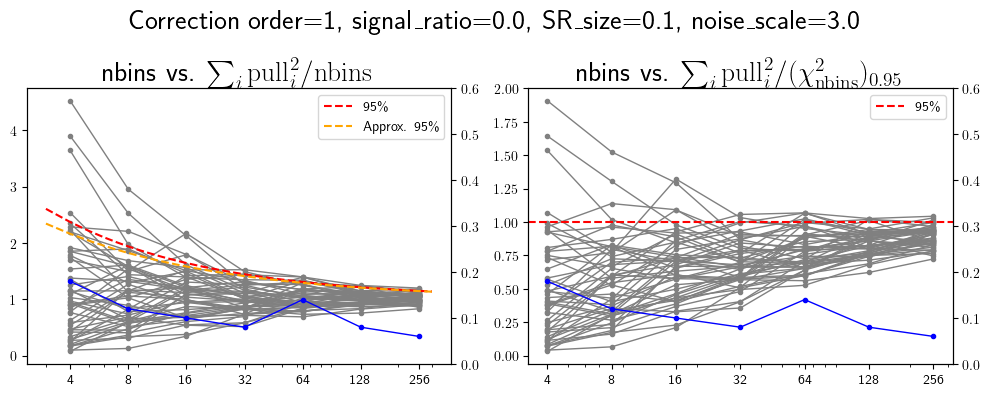

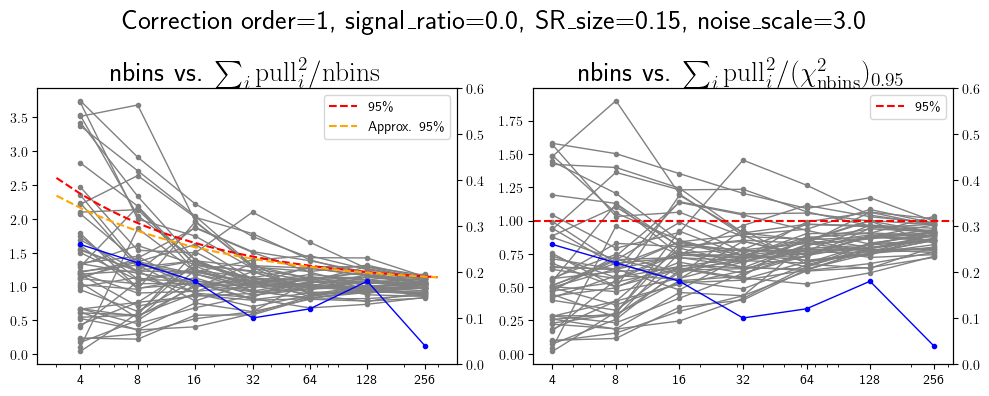

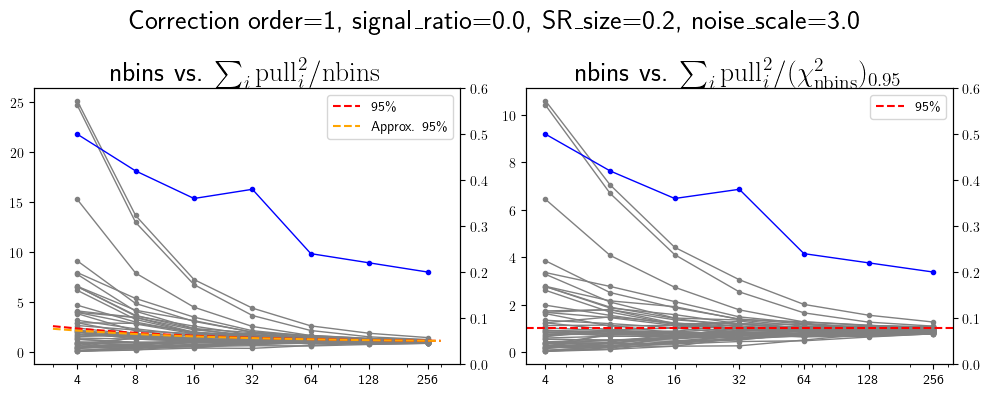

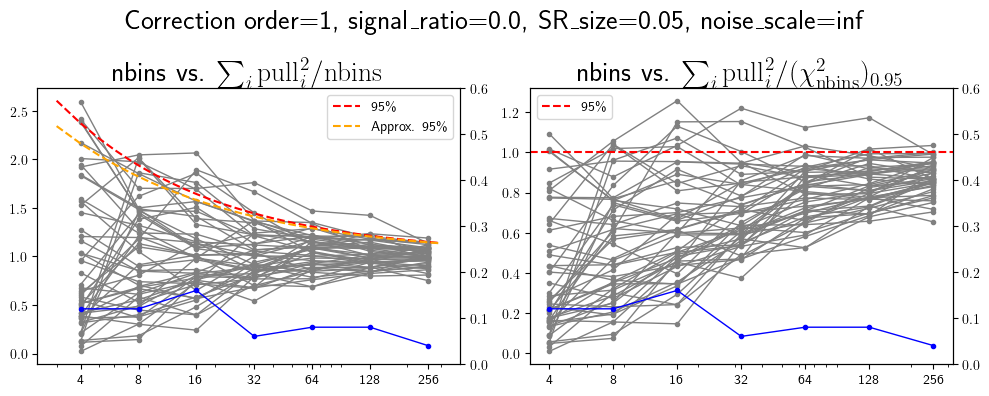

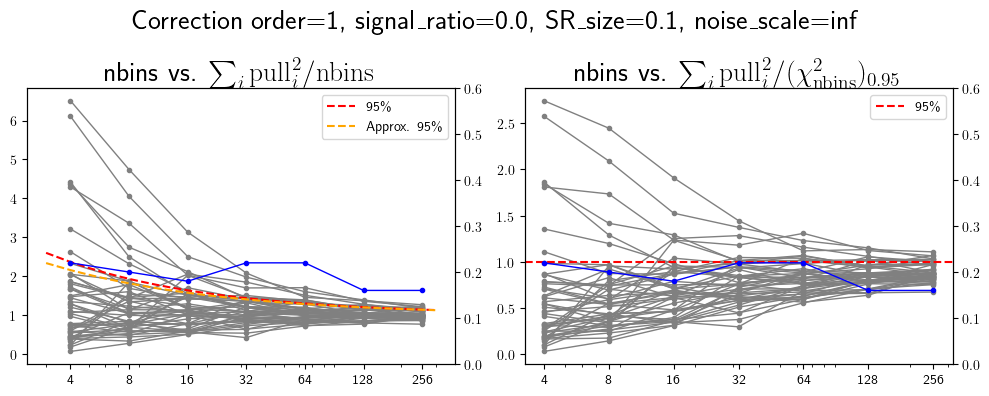

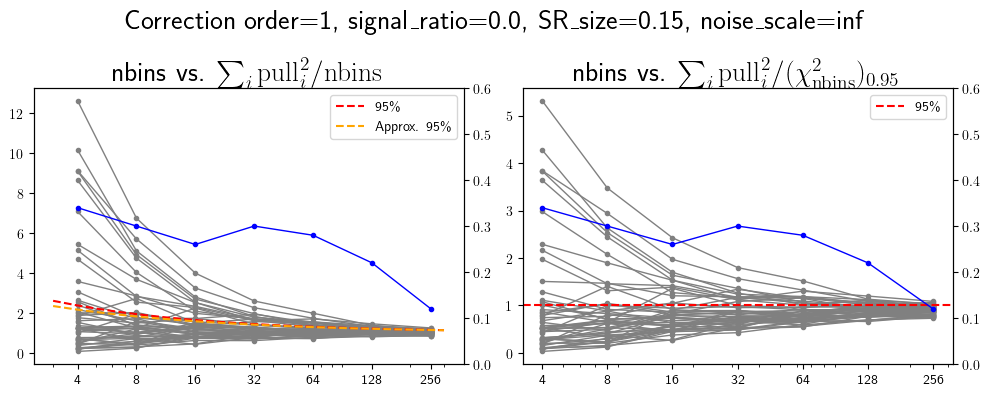

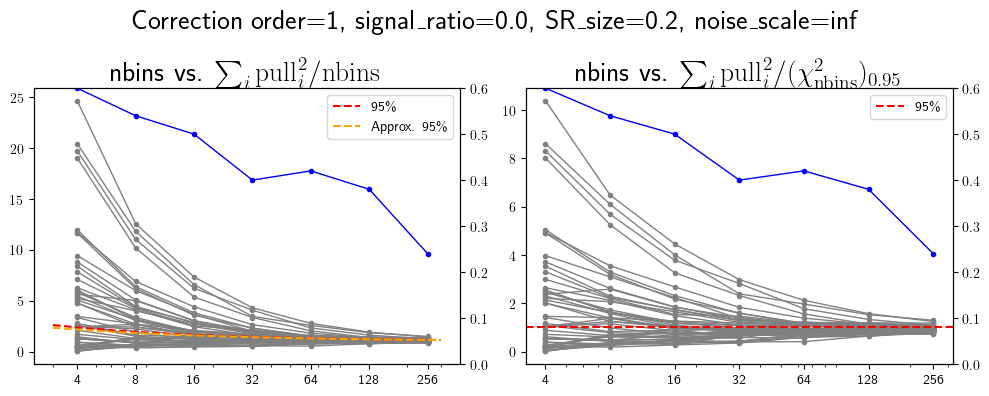

In [8]:
from scipy.stats import chi2, norm
signal_ratio = 0.0
noise_scale = 2.0
for noise_scale in [1.0, 2.0, 3.0, np.inf]:
    for SR_size in [0.05, 0.1, 0.15, 0.2]:
        pull_dicts_null = {k: v for k, v in pull_dicts.items() if (v[0]["signal_ratio"] == signal_ratio 
                                                                    and v[0]["SR_size"] == SR_size
                                                                    and v[0]["noise_scale"] == noise_scale
                                                                    )}    
        pull_list = []
        for hash_ in pull_dicts_null:
            pull_list.extend(pull_dicts_null[hash_])

        pull_df = pd.DataFrame(pull_list)

        tmp_df = pull_df.loc[pull_df["binning_mode"] == "train", ["nbins", "n_eff_bins", 
                                                                "rejected_o0", "rejected_o1", "rejected_o2",
                                                                "pull_o0_sq_sum", "pull_o1_sq_sum", "pull_o2_sq_sum", "seed"]]
        tmp_df_grouped = tmp_df.groupby("seed")


        fig, axs = plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
        fig.suptitle(f"Correction order=1, signal_ratio={signal_ratio}, SR_size={SR_size}, noise_scale={noise_scale}")
        axs[0].set_title(r"nbins vs. $\sum_i {\mathrm{pull}_i^2} / \mathrm{nbins}$")
        for seed in range(50):
            tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
            axs[0].plot(tmp["n_eff_bins"], tmp["pull_o1_sq_sum"] / tmp["n_eff_bins"], marker="o", linewidth=1, 
                    color="gray")
        ax2 = axs[0].twinx()
        nbins_list = 2 ** np.arange(2, 9)
        ax2.plot(nbins_list, tmp_df.groupby("nbins")["rejected_o1"].mean(), marker="o", linewidth=1, color="blue", label="Rejection rate")
        chi2_list = np.arange(3, 300)
        axs[0].plot(chi2_list, chi2.ppf(0.95, chi2_list) / chi2_list, label="95\%", linestyle="--", color="red")    
        axs[0].plot(chi2_list, 1 + norm.ppf(0.95) * np.sqrt(2 / chi2_list), label="Approx. 95\%", linestyle="--", color="orange")    
        ax2.set_ylim(0, 0.6)
        axs[0].set_xscale("log")
        axs[0].set_xticks([2**i for i in range(2, 9)])
        axs[0].set_xticklabels([2**i for i in range(2, 9)])
        axs[0].legend()
        
        axs[1].set_title(r"nbins vs. $\sum_i {\mathrm{pull}_i^2} / (\chi^2_{\mathrm{nbins}})_{0.95}$")
        for seed in range(50):
            tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
            axs[1].plot(tmp["n_eff_bins"], tmp["pull_o1_sq_sum"] / chi2.ppf(0.95, tmp["n_eff_bins"]), marker="o", linewidth=1, 
                    color="gray")
        ax2 = axs[1].twinx()
        nbins_list = 2 ** np.arange(2, 9)
        ax2.plot(nbins_list, tmp_df.groupby("nbins")["rejected_o1"].mean(), marker="o", linewidth=1, color="blue", label="Rejection rate")
        chi2_list = np.arange(3, 300)
        ax2.set_ylim(0, 0.6)
        axs[1].axhline(1, label="95\%", linestyle="--", color="red")    
        axs[1].set_xscale("log")
        axs[1].set_xticks([2**i for i in range(2, 9)])
        axs[1].set_xticklabels([2**i for i in range(2, 9)])
        axs[1].legend()
        plt.tight_layout()
        plt.show()

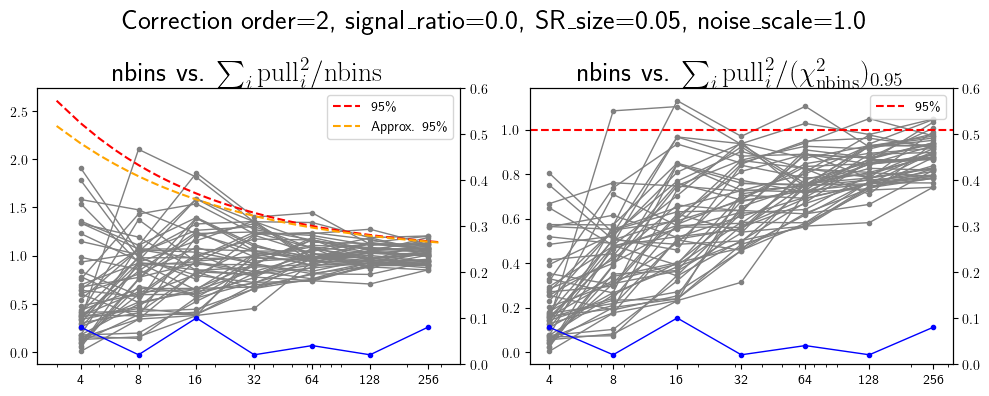

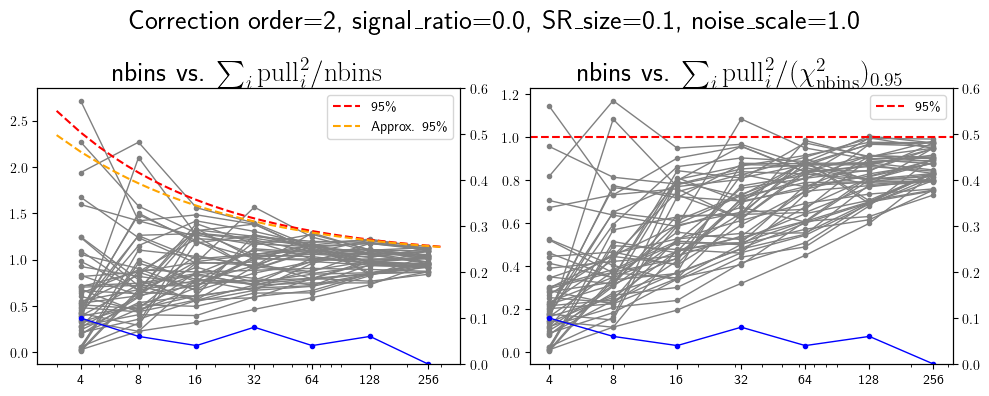

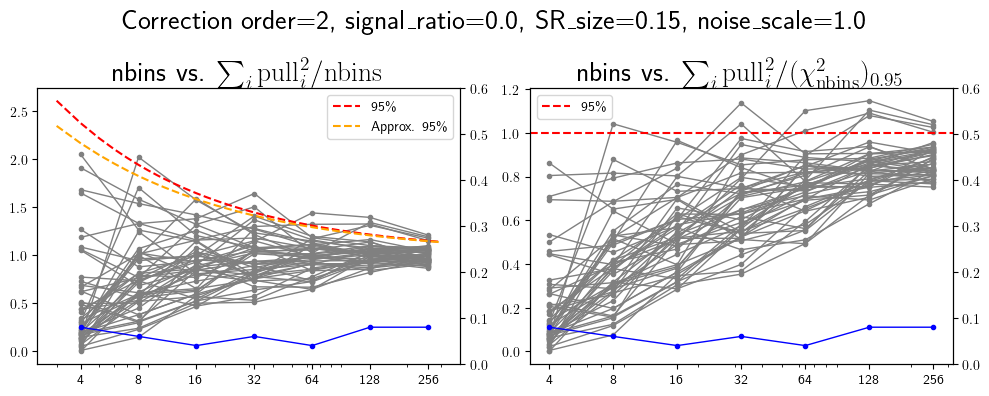

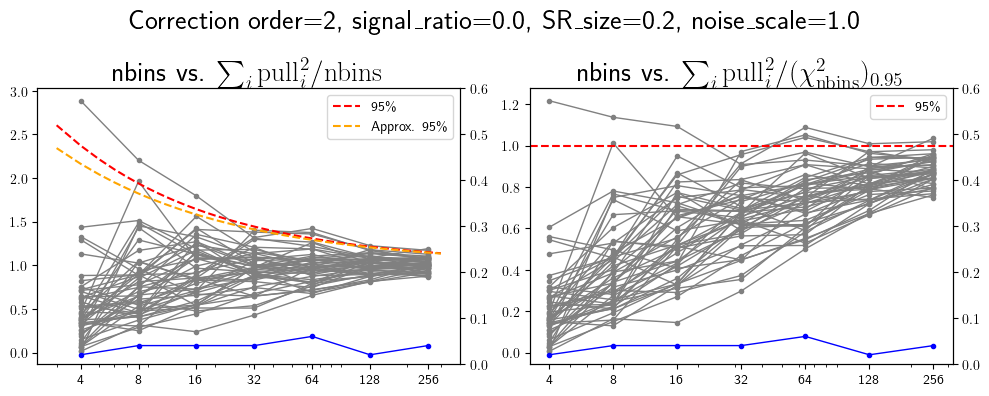

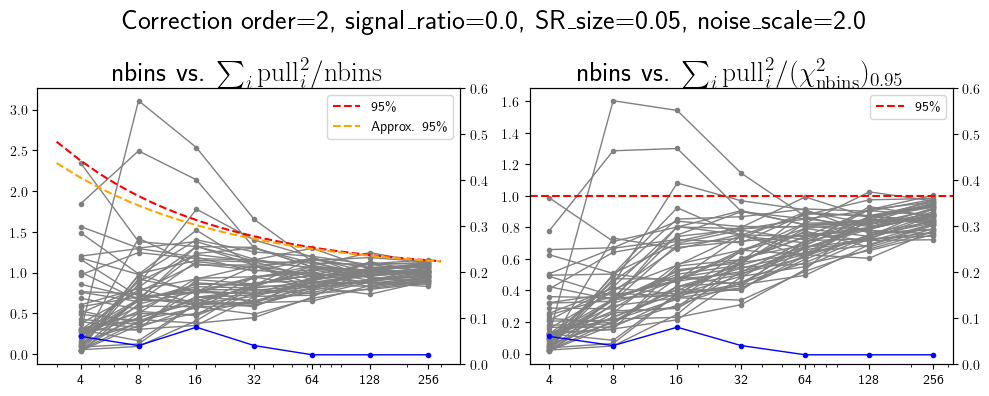

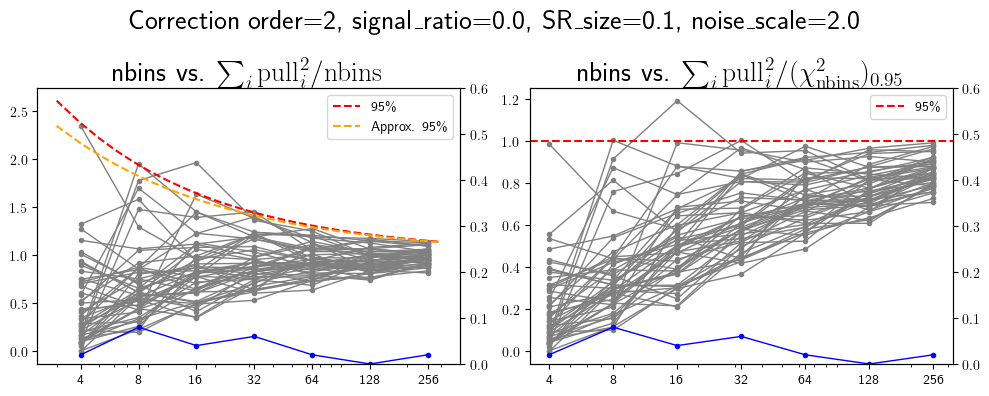

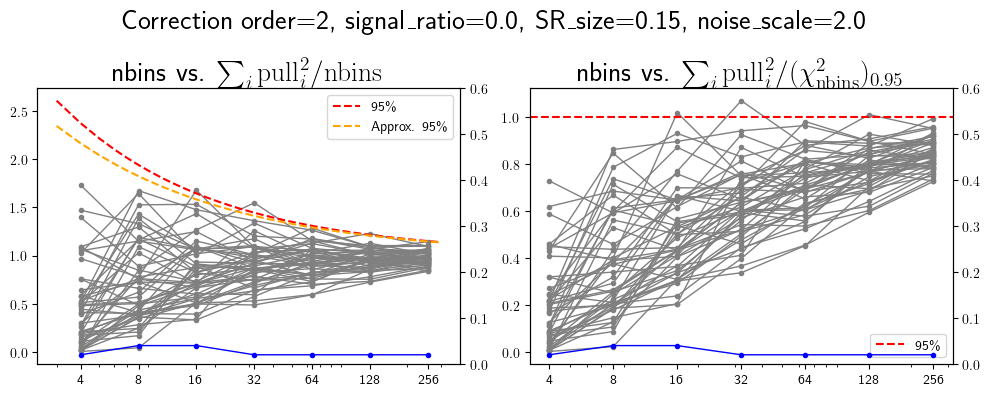

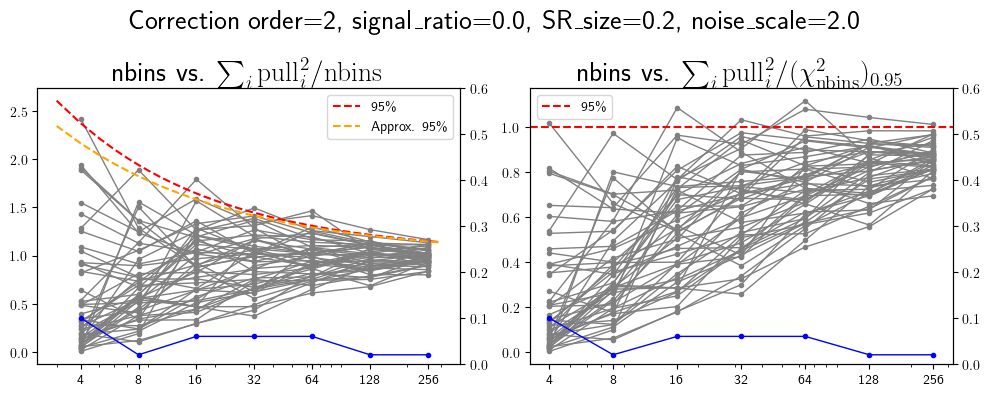

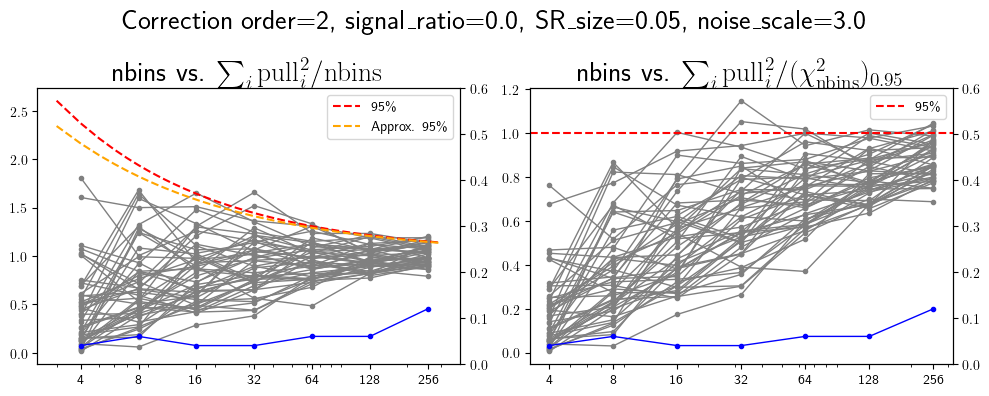

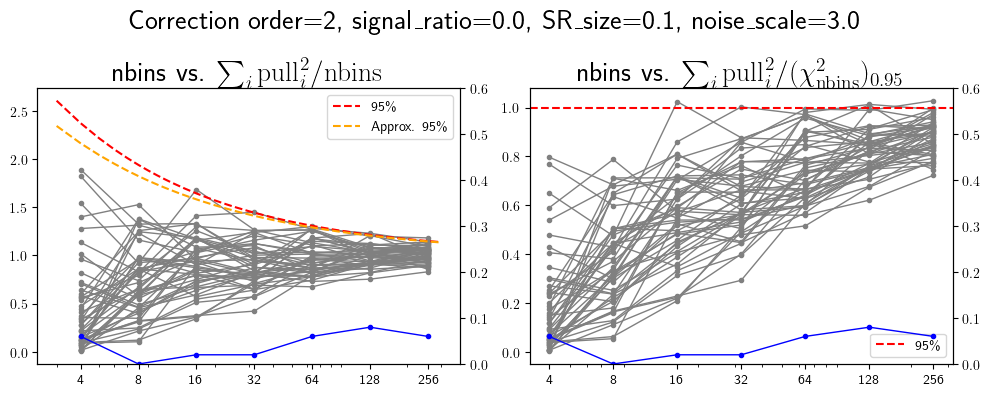

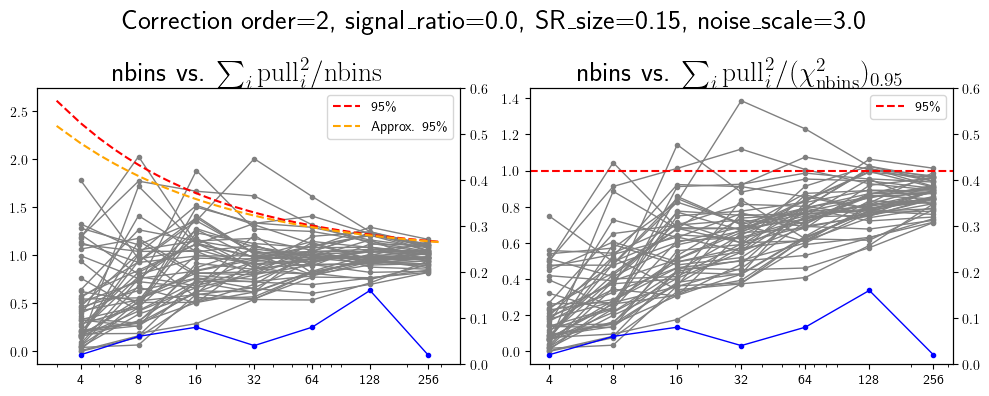

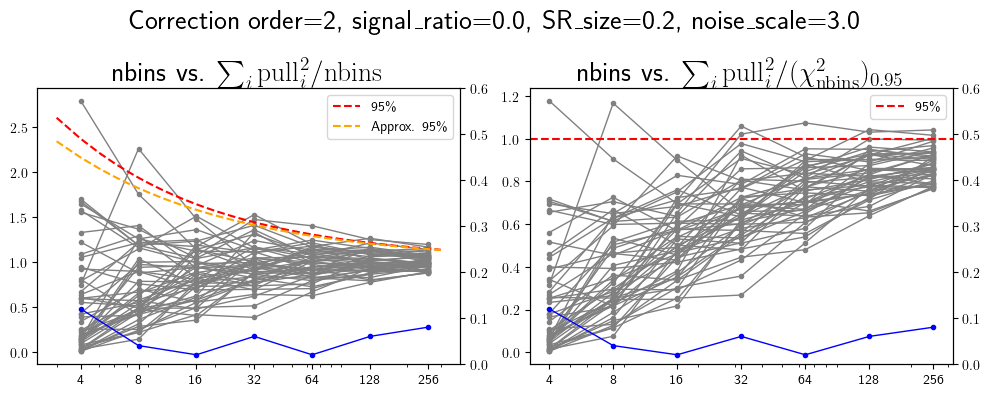

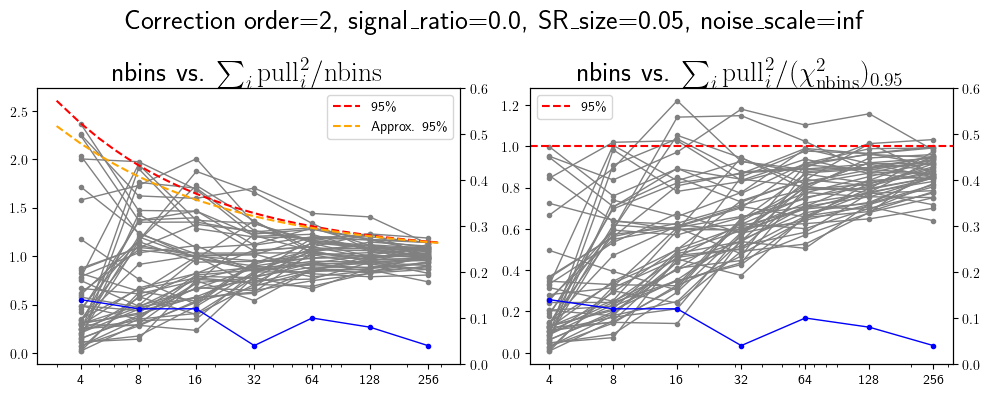

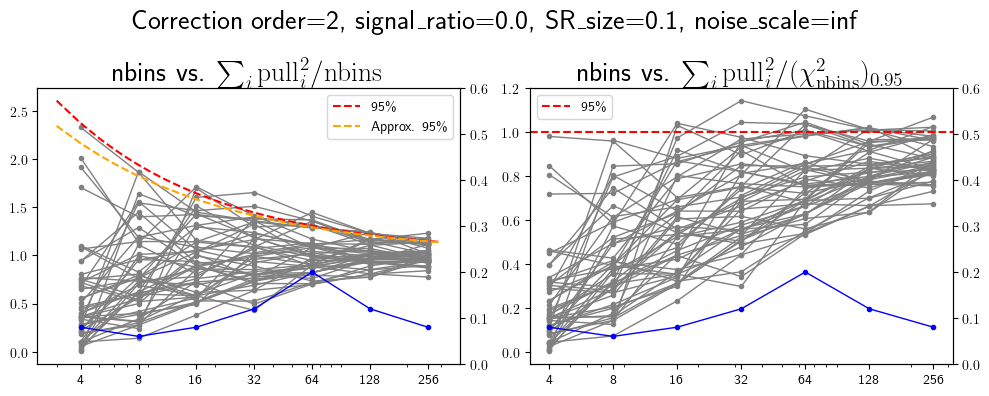

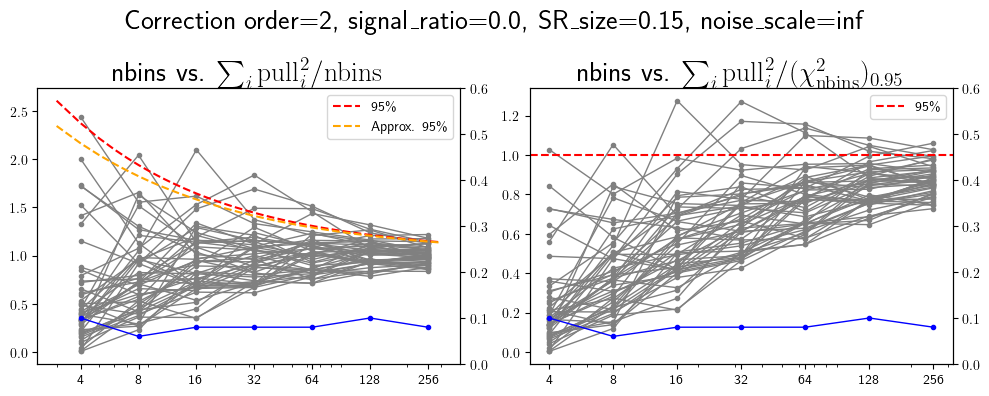

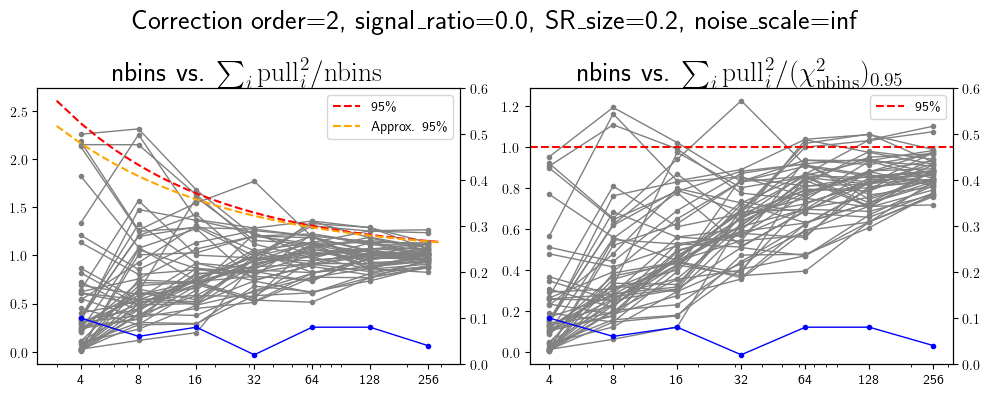

In [9]:
from scipy.stats import chi2, norm
signal_ratio = 0.0
for noise_scale in [1.0, 2.0, 3.0, np.inf]:
    for SR_size in [0.05, 0.1, 0.15, 0.2]:
        pull_dicts_null = {k: v for k, v in pull_dicts.items() if (v[0]["signal_ratio"] == signal_ratio 
                                                                    and v[0]["SR_size"] == SR_size
                                                                    and v[0]["noise_scale"] == noise_scale
                                                                    )}    
        pull_list = []
        for hash_ in pull_dicts_null:
            pull_list.extend(pull_dicts_null[hash_])

        pull_df = pd.DataFrame(pull_list)

        tmp_df = pull_df.loc[pull_df["binning_mode"] == "train", ["nbins", "n_eff_bins", 
                                                                "rejected_o0", "rejected_o1", "rejected_o2",
                                                                "pull_o0_sq_sum", "pull_o1_sq_sum", "pull_o2_sq_sum", "seed"]]
        tmp_df_grouped = tmp_df.groupby("seed")


        fig, axs = plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
        fig.suptitle(f"Correction order=2, signal_ratio={signal_ratio}, SR_size={SR_size}, noise_scale={noise_scale}")
        axs[0].set_title(r"nbins vs. $\sum_i {\mathrm{pull}_i^2} / \mathrm{nbins}$")
        for seed in range(50):
            tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
            axs[0].plot(tmp["n_eff_bins"], tmp["pull_o2_sq_sum"] / tmp["n_eff_bins"], marker="o", linewidth=1, 
                    color="gray")
        ax2 = axs[0].twinx()
        nbins_list = 2 ** np.arange(2, 9)
        ax2.plot(nbins_list, tmp_df.groupby("nbins")["rejected_o2"].mean(), marker="o", linewidth=1, color="blue", label="Rejection rate")
        chi2_list = np.arange(3, 300)
        axs[0].plot(chi2_list, chi2.ppf(0.95, chi2_list) / chi2_list, label="95\%", linestyle="--", color="red")    
        axs[0].plot(chi2_list, 1 + norm.ppf(0.95) * np.sqrt(2 / chi2_list), label="Approx. 95\%", linestyle="--", color="orange")    
        ax2.set_ylim(0, 0.6)
        axs[0].set_xscale("log")
        axs[0].set_xticks([2**i for i in range(2, 9)])
        axs[0].set_xticklabels([2**i for i in range(2, 9)])
        axs[0].legend()
        
        axs[1].set_title(r"nbins vs. $\sum_i {\mathrm{pull}_i^2} / (\chi^2_{\mathrm{nbins}})_{0.95}$")
        for seed in range(50):
            tmp = tmp_df_grouped.get_group(seed).sort_values("n_eff_bins")
            axs[1].plot(tmp["n_eff_bins"], tmp["pull_o2_sq_sum"] / chi2.ppf(0.95, tmp["n_eff_bins"]), marker="o", linewidth=1, 
                    color="gray")
        ax2 = axs[1].twinx()
        nbins_list = 2 ** np.arange(2, 9)
        ax2.plot(nbins_list, tmp_df.groupby("nbins")["rejected_o2"].mean(), marker="o", linewidth=1, color="blue", label="Rejection rate")
        chi2_list = np.arange(3, 300)
        ax2.set_ylim(0, 0.6)
        axs[1].axhline(1, label="95\%", linestyle="--", color="red")    
        axs[1].set_xscale("log")
        axs[1].set_xticks([2**i for i in range(2, 9)])
        axs[1].set_xticklabels([2**i for i in range(2, 9)])
        axs[1].legend()
        plt.tight_layout()
        plt.show()

In [20]:
signal_ratio = 0.0
noise_scale = 1.0
SR_size = 0.2
pull_dicts_null = {k: v for k, v in pull_dicts.items() if (v[0]["signal_ratio"] == signal_ratio 
                                                            and v[0]["SR_size"] == SR_size
                                                            and v[0]["noise_scale"] == noise_scale
                                                            )}    

In [62]:
from signal_region import get_SR_CR_cut, compute_sr_stats
from training_info import TrainingInfo
from constants import FEATURES

SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def compute_hist(x, y, bins=100):
    hist, bins = np.histogram(x, bins=bins)
    hist_wgt, _ = np.histogram(x, bins=bins, weights=y)
    return (bins[1:] + bins[:-1]) / 2, hist_wgt / hist

def load_events_data(hash_: str):
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

def compute_avg_fvt_score(base_fvt_scores: np.ndarray, fvt_scores: np.ndarray) -> np.ndarray:
    bins = np.linspace(0, 1, 100)
    hist_fvt, _ = np.histogram(base_fvt_scores, bins)
    hist_fvt_wgt, _ = np.histogram(base_fvt_scores, bins, weights=fvt_scores)
    midpoints = (bins[1:] + bins[:-1]) / 2
    return midpoints, hist_fvt_wgt / hist_fvt

signal_ratio = 0.0
noise_scale = 1.0
SR_size = 0.2
noise_scale = 1.0
Corr all: 0.413
Corr CR: 0.594
Corr SR: -0.283


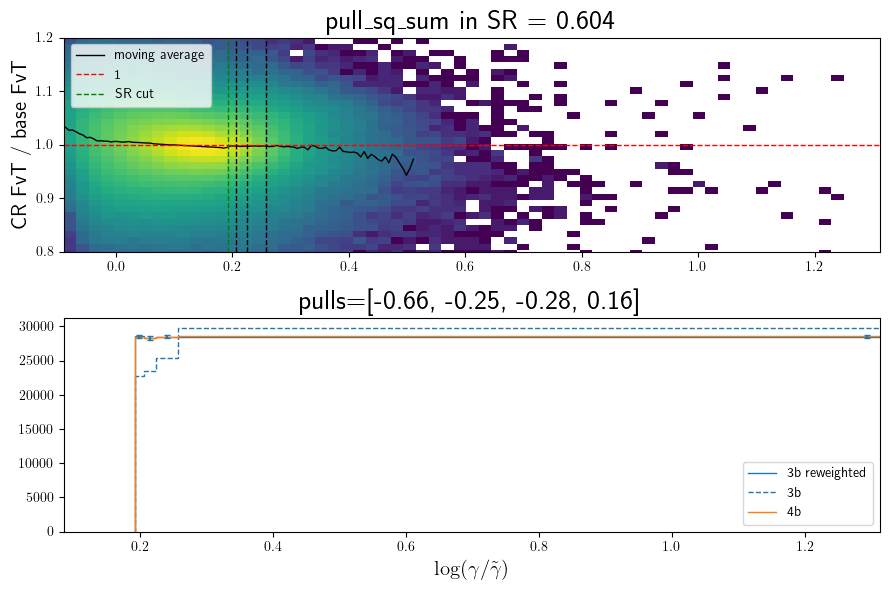

noise_scale = 1.0
Corr all: 0.644
Corr CR: 0.620
Corr SR: 0.068


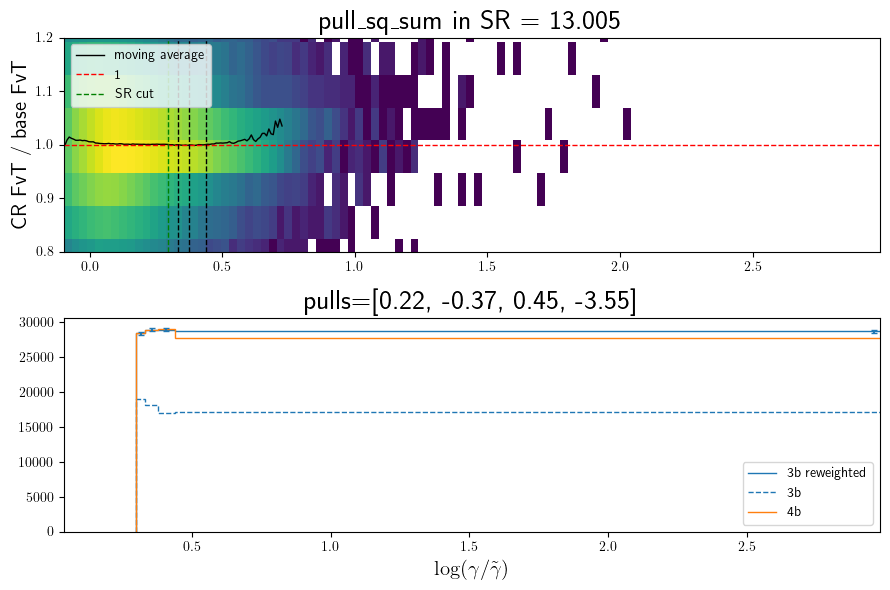

noise_scale = 1.0
Corr all: 0.404
Corr CR: 0.616
Corr SR: -0.182


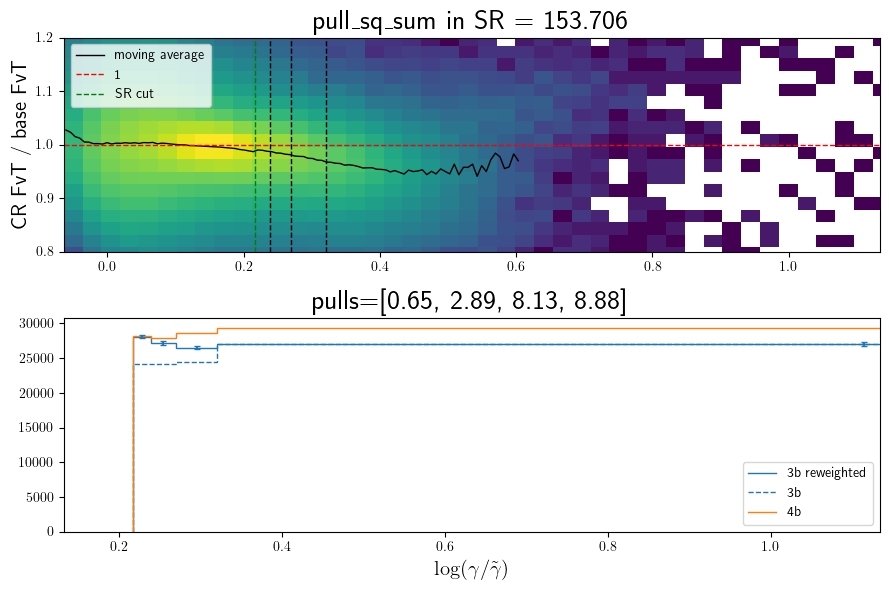

In [70]:
print(f"signal_ratio = {signal_ratio}")
print(f"noise_scale = {noise_scale}")
print(f"SR_size = {SR_size}")

nbins = 4
v_selected = []
for k, v_list in pull_dicts_null.items():
    v = [v for v in v_list if v["nbins"] == nbins][0]
    v_selected.append(v)

sorted_pull_o0_sq_sum = np.argsort([v["pull_o0_sq_sum"] for v in v_selected])
idxs = [sorted_pull_o0_sq_sum[0], sorted_pull_o0_sq_sum[25], sorted_pull_o0_sq_sum[-1]]

for idx in idxs:
    hash_ = list(pull_dicts_null.keys())[idx]
    pull_sq_sum = v_selected[idx]["pull_o0_sq_sum"]
    pull_o0 = v_selected[idx]["pull_o0"]

    events_train, events_tst = load_events_data(hash_)
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])

    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf

    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )

    # Get region cuts and indices
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
    )
    CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
    SR_idx = SR_stats_tst >= SR_cut

    # Calculate FVT scores
    events_tst_CR = events_tst[CR_idx]
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    fvt_scores_train_SR = CR_fvt_tinfo.aux_info["fvt_scores_train_SR"]
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    fvt_scores_tst_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].numpy()

    # Calculate correlations
    corr_CR = np.corrcoef(SR_stats_tst[CR_idx], fvt_scores_tst_CR)[0, 1]
    corr_SR = np.corrcoef(SR_stats_tst[SR_idx], fvt_scores_tst_SR)[0, 1]
    fvt_scores_all = np.zeros_like(SR_stats_tst)
    fvt_scores_all[CR_idx] = fvt_scores_tst_CR
    fvt_scores_all[SR_idx] = fvt_scores_tst_SR
    corr_all = np.corrcoef(SR_stats_tst, fvt_scores_all)[0, 1]

    print(f"noise_scale = {noise_scale}")
    print(f"Corr all: {corr_all:.3f}")
    print(f"Corr CR: {corr_CR:.3f}")
    print(f"Corr SR: {corr_SR:.3f}")

    base_fvt_scores_tst = []
    for hash_ in SR_stats_hashes:
        smeared_tinfo = TrainingInfo.load(hash_)
        base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
        base_fvt_logits_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
        base_fvt_score_tst = np.exp(base_fvt_logits_tst) / (np.exp(base_fvt_logits_tst) + 1)
        base_fvt_scores_tst.append(base_fvt_score_tst)
        
    base_fvt_scores_tst = np.mean(base_fvt_scores_tst, axis=0)

    # Combine data for plots
    fvt_scores_all = np.concatenate([fvt_scores_tst_CR, fvt_scores_tst_SR])
    base_fvt_scores_all = np.concatenate([base_fvt_scores_tst[CR_idx], base_fvt_scores_tst[SR_idx]])
    SR_stats_all = np.concatenate([SR_stats_tst[CR_idx], SR_stats_tst[SR_idx]])
    is_3b_all = np.concatenate([events_tst.is_3b[CR_idx], events_tst.is_3b[SR_idx]])

    # cut outliers
    from correct_systematic_error import get_histograms
    from utils import get_quantiles_with_weights


    outliers = np.quantile(SR_stats_all, 0.999)
    cut_idx = SR_stats_all < outliers

    fig, axs = plt.subplots(figsize=(9, 6), nrows=2, ncols=1)
    axs[0].hist2d(SR_stats_all, fvt_scores_all / base_fvt_scores_all, bins=100, 
                  norm=LogNorm())
    x, y = compute_hist(SR_stats_all[cut_idx], fvt_scores_all[cut_idx] / base_fvt_scores_all[cut_idx], bins=100)
    axs[0].plot(x, y, label="moving average", linewidth=1, color="black")
    axs[0].axhline(1, label="1", linewidth=1, color="red", linestyle="--")
    axs[0].axvline(SR_cut, label="SR cut", linewidth=1, color="green", linestyle="--")
    axs[0].set_ylabel(r"CR FvT / base FvT")
    axs[0].legend(loc="upper left")
    axs[0].set_title(f"pull_sq_sum in SR = {pull_sq_sum:.3f}")

    events_tst_SR = events_tst[SR_idx]
    events_train_SR = events_train[SR_stats_train >= SR_cut]
    bin_stats_tst_SR = SR_stats_tst[SR_idx]
    bin_stats_train_SR = SR_stats_train[SR_stats_train >= SR_cut]
    reweights_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    reweights_train_SR = fvt_scores_train_SR / (1 - fvt_scores_train_SR)
    reweights_train_SR = np.where(events_train_SR.is_4b, 1, reweights_train_SR)
    SR_bins = get_quantiles_with_weights(
                    bin_stats_train_SR[events_train_SR.is_3b],
                    (reweights_train_SR * events_train_SR.weights)[events_train_SR.is_3b],
                    np.linspace(0, 1, nbins + 1),
                )
    for bin_edge in SR_bins[1:]:
        axs[0].axvline(bin_edge, label="bin edges", linewidth=1, color="black", linestyle="--")

    hists = get_histograms(events_tst_SR, bin_stats_tst_SR, SR_bins, reweights_SR)
    error = np.sqrt(hists["3b_rw"] + hists["4b"])

    colors = plt.cm.tab10
    axs[1].stairs(hists["3b_rw"], SR_bins, label="3b reweighted", color=colors(0))
    axs[1].stairs(hists["3b"], SR_bins, label="3b", color=colors(0), linestyle="--")
    axs[1].stairs(hists["4b"], SR_bins, label="4b", color=colors(1))
    midpoints = (SR_bins[:-1] + SR_bins[1:]) / 2
    axs[1].errorbar(midpoints, hists["3b_rw"], error, color=colors(0), capsize=2, linestyle="")
    axs[1].legend(loc="lower right")
    axs[1].set_xlabel(r"$\log (\gamma / \tilde{\gamma})$")
    axs[1].set_title(f"pulls={[np.round(p, 2) for p in pull_o0]}")
    
    axs[0].set_ylim(0.8, 1.2)
    xlim = axs[0].get_xlim()
    axs[0].set_xlim(xlim[0], midpoints[-1] + 0.02)
    xlim = axs[1].get_xlim()
    axs[1].set_xlim(xlim[0], midpoints[-1] + 0.02)
    
    plt.tight_layout()
    plt.show()

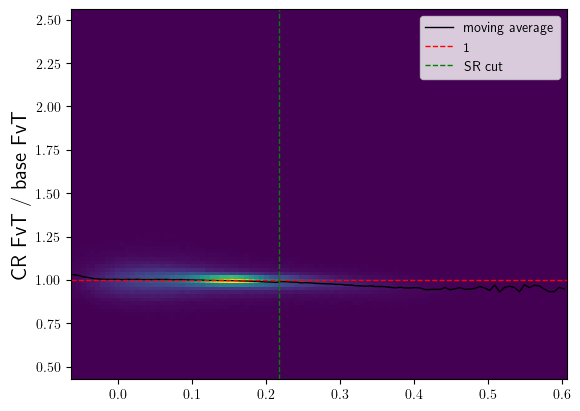

In [25]:
# cut outliers
outliers = np.quantile(SR_stats_all, 0.999)
cut_idx = SR_stats_all < outliers
# plt.scatter(SR_stats_all[cut_idx & is_3b_all], fvt_scores_all[cut_idx & is_3b_all] / base_fvt_scores_all[cut_idx & is_3b_all], s=1, alpha=0.1)
plt.hist2d(SR_stats_all[cut_idx & is_3b_all], 
           fvt_scores_all[cut_idx & is_3b_all] / base_fvt_scores_all[cut_idx & is_3b_all], 
           bins=100)
x, y = compute_hist(SR_stats_all[cut_idx & is_3b_all], fvt_scores_all[cut_idx & is_3b_all] / base_fvt_scores_all[cut_idx & is_3b_all], bins=100)
plt.plot(x, y, label="moving average", linewidth=1, color="black")
plt.axhline(1, label="1", linewidth=1, color="red", linestyle="--")
plt.axvline(SR_cut, label="SR cut", linewidth=1, color="green", linestyle="--")
# plt.xlabel(r"\log (\gamma / \tilde{\gamma})")
plt.ylabel(r"CR FvT / base FvT")
plt.legend()
plt.show()